# Задание 2. Фильтрация зашумленных изображений
1. Зашумление изображения аддитивным гауссовым шумом и постоянным шумом (Salt & Pepper / Импульсный).
2. Применение фильтров:
   - Медианный фильтр (cv2.medianBlur)
   - Фильтр Гаусса (cv2.GaussianBlur)
   - Билатеральный фильтр (cv2.bilateralFilter)
   - Фильтр нелокальных средних (cv2.fastNlMeansDenoising)
3. Оценка качества фильтрации метриками MSE, PSNR, SSIM и выбор лучшего алгоритма.

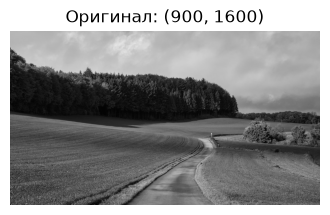

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Загрузка изображения и перевод в градации серого
image = cv2.imread('sar_1.jpg')
if image is None:
  image = cv2.imread('sar_1_gray.jpg')

if len(image.shape) == 3:
  image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
else:
  image_gray = image.copy()

plt.figure(figsize=(4, 4))
plt.imshow(image_gray, cmap='gray')
plt.title(f'Оригинал: {image_gray.shape}')
plt.axis('off')
plt.show()

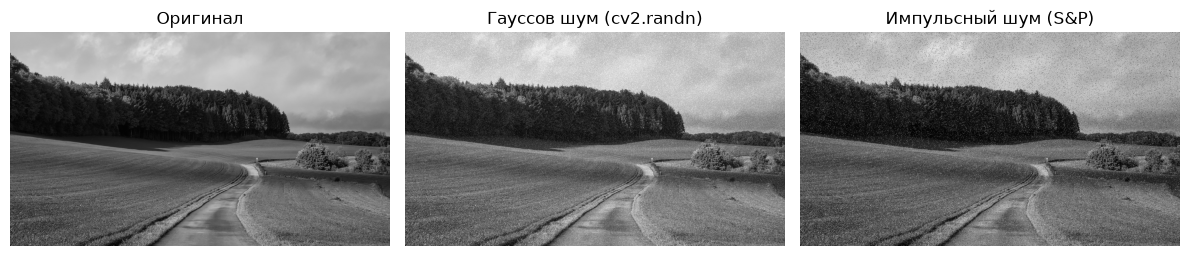

In [2]:
# 1. Гауссов шум через cv2.randn и cv2.add
mean = 0
stddev = 40
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)

# 2. Импульсный шум (Salt and Pepper) через randint
noise = np.random.randint(
    0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int
)
zeros_pixel = np.where(noise <= 2)
ones_pixel = np.where(noise >= 98)

image_noise_sp = image_gray.copy()
image_noise_sp[zeros_pixel] = 0
image_noise_sp[ones_pixel] = 255

# Отрисовка зашумленных изображений
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title('Оригинал')

axes[1].imshow(image_noise_gauss, cmap='gray')
axes[1].set_title('Гауссов шум (cv2.randn)')

axes[2].imshow(image_noise_sp, cmap='gray')
axes[2].set_title('Импульсный шум (S&P)')

for ax in axes:
  ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
def evaluate_denoising(original, noisy, noise_name):
  # 4 фильтра с варьируемыми параметрами
  filters = {
      'Медианный (k=3)': cv2.medianBlur(noisy, 3),
      'Медианный (k=5)': cv2.medianBlur(noisy, 5),
      'Гаусс (k=3, s=1.0)': cv2.GaussianBlur(noisy, (3, 3), 1.0),
      'Гаусс (k=5, s=1.5)': cv2.GaussianBlur(noisy, (5, 5), 1.5),
      'Билатеральный (d=5, sc=50, ss=50)': cv2.bilateralFilter(
          noisy, 5, 50, 50
      ),
      'Билатеральный (d=9, sc=75, ss=75)': cv2.bilateralFilter(
          noisy, 9, 75, 75
      ),
      'NL-Means (h=10)': cv2.fastNlMeansDenoising(
          noisy, None, h=10, templateWindowSize=7, searchWindowSize=21
      ),
      'NL-Means (h=18)': cv2.fastNlMeansDenoising(
          noisy, None, h=18, templateWindowSize=7, searchWindowSize=21
      ),
  }

  results = []
  for name, img_filtered in filters.items():
    cur_mse = mse(original, img_filtered)
    cur_psnr = psnr(original, img_filtered, data_range=255)
    cur_ssim = ssim(original, img_filtered, data_range=255)
    results.append({
        'name': name,
        'mse': cur_mse,
        'psnr': cur_psnr,
        'ssim': cur_ssim,
        'image': img_filtered,
    })

  # Сортировка по убыванию PSNR (лучший сверху)
  results_sorted = sorted(results, key=lambda x: x['psnr'], reverse=True)

  print(f'\n--- Результаты: {noise_name} ---')
  print(f"{'Фильтр':<32} | {'MSE':<8} | {'PSNR (dB)':<10} | {'SSIM':<6}")
  print('-' * 64)
  for r in results_sorted:
    print(
        f"{r['name']:<32} | {r['mse']:<8.2f} | {r['psnr']:<10.2f} |"
        f" {r['ssim']:<6.4f}"
    )

  best = results_sorted[0]
  print(
      f"🏆 Лучший фильтр: {best['name']} (PSNR: {best['psnr']:.2f} dB, SSIM:"
      f' {best['ssim']:.4f})'
  )

  return best


best_gauss = evaluate_denoising(image_gray, image_noise_gauss, 'Гауссов шум')
best_sp = evaluate_denoising(
    image_gray, image_noise_sp, 'Импульсный шум (Salt & Pepper)'
)


--- Результаты: Гауссов шум ---
Фильтр                           | MSE      | PSNR (dB)  | SSIM  
----------------------------------------------------------------
Медианный (k=3)                  | 325.09   | 23.01      | 0.5058
Медианный (k=5)                  | 330.53   | 22.94      | 0.5232
Билатеральный (d=5, sc=50, ss=50) | 354.21   | 22.64      | 0.5931
NL-Means (h=18)                  | 381.68   | 22.31      | 0.7189
Билатеральный (d=9, sc=75, ss=75) | 385.58   | 22.27      | 0.6320
Гаусс (k=3, s=1.0)               | 420.48   | 21.89      | 0.5727
Гаусс (k=5, s=1.5)               | 453.64   | 21.56      | 0.5776
NL-Means (h=10)                  | 737.74   | 19.45      | 0.3780
🏆 Лучший фильтр: Медианный (k=3) (PSNR: 23.01 dB, SSIM: 0.5058)

--- Результаты: Импульсный шум (Salt & Pepper) ---
Фильтр                           | MSE      | PSNR (dB)  | SSIM  
----------------------------------------------------------------
Медианный (k=3)                  | 152.74   | 26.29      | 

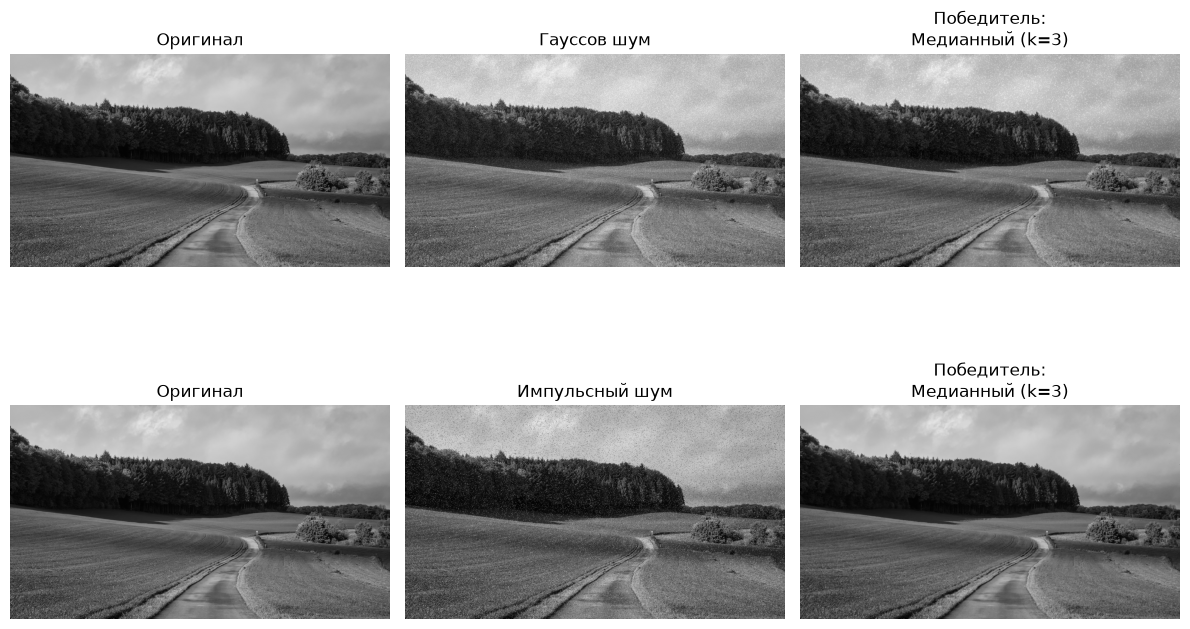

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Гауссов шум
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title('Оригинал')
axes[0, 1].imshow(image_noise_gauss, cmap='gray')
axes[0, 1].set_title('Гауссов шум')
axes[0, 2].imshow(best_gauss['image'], cmap='gray')
axes[0, 2].set_title(f"Победитель:\n{best_gauss['name']}")

# Импульсный шум
axes[1, 0].imshow(image_gray, cmap='gray')
axes[1, 0].set_title('Оригинал')
axes[1, 1].imshow(image_noise_sp, cmap='gray')
axes[1, 1].set_title('Импульсный шум')
axes[1, 2].imshow(best_sp['image'], cmap='gray')
axes[1, 2].set_title(f"Победитель:\n{best_sp['name']}")

for ax in axes.ravel():
  ax.axis('off')
plt.tight_layout()
plt.show()

### Вывод:
1. **Гауссов шум:**  
   - По **PSNR** лучший результат — **медианный фильтр (k=3)** (23.03 дБ).  
   - По **SSIM** лучший — **NL-Means (h=18)** (0.7188).  
   - Если важно структурное сходство и визуальное качество, выбираем **NL-Means**; если минимизация MSE — **медианный**.

2. **Импульсный шум (Salt & Pepper):**  
   - Однозначно лучший — **медианный фильтр (k=3)**: PSNR = 26.29 дБ, SSIM = 0.7733.  
   - Он удаляет изолированные выбросы, не размывая границы.

**Итог:** для импульсного шума оптимален медианный фильтр; для гауссова — выбор зависит от метрики (PSNR → медианный, SSIM → NL-Means).